## Импорты 

In [1]:

import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from itertools import chain
from sklearn.preprocessing import LabelEncoder
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from datetime import timedelta
from collections import Counter
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim import AdamW
from typing import Dict, Union


## Загрузка датасетов

In [2]:
# Считываем датасеты
df_items = pd.read_csv('./dataset/KION_DATASET/data_en/items_en.csv')
df_users = pd.read_csv('./dataset/KION_DATASET/data_en/users_en.csv')
df_interactions = pd.read_csv('./dataset/KION_DATASET/interactions.csv')

In [3]:
df_interactions = df_interactions[df_interactions['user_id'].isin(df_users['user_id'])].copy()
df_interactions = df_interactions[df_interactions['item_id'].isin(df_items['item_id'])].copy()
# Убираем интеракции пользователей и фильмов, которых нет в других df
df_users = df_users.drop("Unnamed: 0", axis=1)
df_items = df_items.drop("Unnamed: 0", axis=1)
# Убираем пустые столбцы

## Обработка Интеракций

In [4]:
def check_date_with_formats(df, column_name, date_formats=None):
    """
    Проверяет даты в указанном столбце DataFrame, пробуя несколько форматов, и возвращает наилучший формат.  

    Аргументы:  

        df: pandas DataFrame  
        column_name: str — имя столбца с датами  
        date_formats: list, optional — список форматов для проверки (по умолчанию: ['%Y-%m-%d', '%d.%m.%Y', '%m/%d/%Y', '%Y-%m-%d %H:%M:%S'])  

    Возвращает:  

        dict с ключами: 'best_format' (наилучший формат), 'valid_count_with_best_format' (количество успешно преобразованных значений), 'all_results' (словарь форматов с количеством успехов)  
    """
    if date_formats is None:
        date_formats = ['%Y-%m-%d', '%d.%m.%Y', '%m/%d/%Y', '%Y-%m-%d %H:%M:%S']
    
    results = {}
    
    for date_format in date_formats:
        try:
            # Пробуем преобразовать с конкретным форматом
            converted = pd.to_datetime(df[column_name], format=date_format, errors='coerce')
            valid_count = converted.notna().sum()
            results[date_format] = valid_count
        except Exception:
            results[date_format] = 0
    
    # Находим лучший формат
    best_format = max(results.items(), key=lambda x: x[1])
    
    return {
        'best_format': best_format[0] if best_format[1] > 0 else None,
        'valid_count_with_best_format': best_format[1],
        'all_results': results
    }

def convert_to_datetime(series):
    """
    Преобразует серию строк с датами в pandas datetime, используя два возможных формата: '%Y-%m-%d' и '%d %m %Y'.  
    
    Аргументы:  
        
        series: pandas Series — строки с датами  
    
    Возвращает:  
        
        pandas Series с объектами datetime (или NaT для некорректных значений)  
    """
    result = pd.Series(index=series.index, dtype='object')
    idx1 = ['-' in i if i is not None else True  for i in series] # Ищет формат даты через "-" и None
    idx2 = [not i for i in idx1] # Делает замену True на False и False на True
    result[idx1] = pd.to_datetime(series[idx1], format='%Y-%m-%d')
    result[idx2] = pd.to_datetime(series[idx2], format='%d %m %Y')
    
    return result

In [5]:
df_inter_for_ds = df_interactions.drop(['total_dur'], axis=1, inplace=False).copy()

format_check = check_date_with_formats(df_inter_for_ds, 'last_watch_dt')
print("Результаты проверки форматов:")
for key, value in format_check.items():
    print(f"{key}: {value}")
     

print(df_inter_for_ds["item_id"].count())


df_inter_for_ds.loc[:, "date_w"] = convert_to_datetime (df_inter_for_ds["last_watch_dt"])
# Зачищаем даты 

Результаты проверки форматов:
best_format: %Y-%m-%d
valid_count_with_best_format: 1288996
all_results: {'%Y-%m-%d': np.int64(1288996), '%d.%m.%Y': np.int64(0), '%m/%d/%Y': np.int64(0), '%Y-%m-%d %H:%M:%S': np.int64(0)}
1288996


In [6]:
# делим на трейн и тест
df_inter_for_ds.sort_values(by = "date_w",  ascending=False)
df_inter_for_ds.drop(columns=["last_watch_dt"],inplace=True)

days = 21
last_date = df_inter_for_ds["date_w"].max()

df_interactions_train = df_inter_for_ds[df_inter_for_ds["date_w"] < last_date - timedelta(days=days)].copy()

df_interactions_test = df_inter_for_ds[df_inter_for_ds["date_w"] >= last_date - timedelta(days=days)].copy()

In [7]:
# Кодируем категориальные признаки
le_age = LabelEncoder()
le_inc = LabelEncoder()
le_sex = LabelEncoder()
df_users["age_en"] = le_age.fit_transform(df_users["age"])
df_users["income_en"] = le_inc.fit_transform(df_users["income"])
df_users["sex_en"] = le_inc.fit_transform(df_users["sex"])
df_users.head()

,user_id,age,income,sex,kids_flg,age_en,income_en,sex_en
0,973171,age_25_34,income_60_90,M,1,1,4,1
1,962099,age_18_24,income_20_40,M,0,0,2,1
2,1047345,age_45_54,income_40_60,F,0,3,3,0
3,721985,age_45_54,income_20_40,F,0,3,2,0
4,704055,age_35_44,income_60_90,F,0,2,4,0


In [8]:
def check_nan (df):
    """
    Проверяет наличие пропущенных значений в DataFrame, выводит информацию о столбцах с NaN и количество не-NaN значений.

    Аргументы:

        df: pandas DataFrame
    """
    # Проверка, есть ли вообще NaN значения в DataFrame
    has_any_nans = df.isna().any().any()
    print(f"Есть ли NaN в DataFrame: {has_any_nans}")

    # Столбцы, содержащие хотя бы один NaN
    columns_with_nans = df.columns[df.isna().any()].tolist()
    print(f"Столбцы с NaN: {columns_with_nans}")

    # Количество не-NaN значений
    non_nan_count = df.count()  # По столбцам
    print("Не-NaN значений по столбцам:")
    print(non_nan_count)
    

In [9]:
check_nan (df_interactions_train)

# Удаляем все строки, где есть хотя бы один NaN
df_inter_for_ds_cleaned = df_interactions_train.dropna()

check_nan (df_inter_for_ds_cleaned)

Есть ли NaN в DataFrame: True
Столбцы с NaN: ['watched_pct']
Не-NaN значений по столбцам:
user_id        994764
item_id        994764
watched_pct    994556
date_w         994764
dtype: int64
Есть ли NaN в DataFrame: False
Столбцы с NaN: []
Не-NaN значений по столбцам:
user_id        994556
item_id        994556
watched_pct    994556
date_w         994556
dtype: int64


In [10]:
check_nan (df_interactions_test)

# Удаляем все строки, где есть хотя бы один NaN
df_inter_for_test_cleaned = df_interactions_test.dropna()

check_nan (df_inter_for_test_cleaned)

Есть ли NaN в DataFrame: True
Столбцы с NaN: ['watched_pct']
Не-NaN значений по столбцам:
user_id        294232
item_id        294232
watched_pct    294230
date_w         294232
dtype: int64
Есть ли NaN в DataFrame: False
Столбцы с NaN: []
Не-NaN значений по столбцам:
user_id        294230
item_id        294230
watched_pct    294230
date_w         294230
dtype: int64


## Обработка фильмов

In [11]:
def split_and_clean(text):
    """
    Разделяет строку по запятым, удаляет лишние пробелы и приводит к нижнему регистру. Используется для обработки списков жанров и ключевых слов.

    Аргументы:

        text: str или NaN

    Возвращает:

        list[str] — список токенов, или [] если входное значение NaN.
    """
    if pd.isna(text):
        return []
    return [t.strip().lower() for t in text.split(',') if t.strip()]

df_items['genres_list'] = df_items['genres'].apply(split_and_clean)
df_items['keywords_list'] = df_items['keywords'].apply(split_and_clean)
#Преобразуем строки в списки жанров и ключевых слов

In [12]:

def build_vocab(list_column, min_freq=5):
    """
Строит словарь (vocab) из списка списков токенов, включая специальные токены '<PAD>' и '<UNK>'. Токены с частотой ниже min_freq игнорируются.

Аргументы:

    list_column: list of list of str — список документов, каждый документ — список токенов

    min_freq: int, default=5 — минимальная частота токена для включения в словарь

Возвращает:

    dict {token: idx}
    """
    counter = Counter()
    
    for tokens in list_column:
        counter.update(tokens)

    vocab = {"<PAD>": 0, "<UNK>": 1}

    idx = 2
    for token, freq in counter.items():
        if freq >= min_freq:
            vocab[token] = idx
            idx += 1

    return vocab

def tokens_to_indices(tokens, vocab):
    """
Преобразует список токенов в список индексов, используя переданный словарь. Токены, отсутствующие в словаре, пропускаются.

Аргументы:

    tokens: list of str

    vocab: dict {token: idx}

Возвращает:

    list of int — индексы токенов, присутствующих в словаре
    """
    return [vocab[t] for t in tokens if t in vocab]


genres_vocab = build_vocab(df_items['genres_list'], min_freq=1)
keywords_vocab = build_vocab(df_items['keywords_list'], min_freq=5)
# Создаем два словаря для жанров и ключевых слов 

print(len(genres_vocab), len(keywords_vocab))

158 5845


In [13]:
# Функция для вычисления IDF
def compute_idf(vocab, token_lists):
    """
Вычисляет IDF (обратную частоту документа) для каждого токена в словаре на основе списка списков токенов.

Аргументы:

    vocab: dict {token: idx}

    token_lists: list of list of str — токены для каждого документа

Возвращает:

    dict {token: idf} — IDF для каждого токена (для '<PAD>' и '<UNK>' IDF = 0.0)
    """
    n_docs = len(token_lists)
    doc_freq = Counter()
    for tokens in token_lists:
        unique_tokens = set(tokens)
        doc_freq.update(unique_tokens)
    
    idf = {}
    for token, idx in vocab.items():
        if token in ['<PAD>', '<UNK>']:
            idf[token] = 0.0
        else:
            # Сглаженная IDF
            idf[token] = np.log((n_docs + 1) / (doc_freq[token] + 1)) + 1
    return idf

def build_weight_tensor(tokens_idx, idx_to_token, idf_dict, max_len):
    """
Создает тензор весов для последовательности индексов токенов на основе IDF. Обрезает до max_len и дополняет нулями.

Аргументы:

    tokens_idx: list of int — индексы токенов

    idx_to_token: dict {idx: token}

    idf_dict: dict {token: float}

    max_len: int

Возвращает:

    torch.Tensor формы (max_len,) — веса (IDF) для каждого токена (или 0 для PAD)
    """
    # Обрезаем список до max_len
    tokens_idx = tokens_idx[:max_len]
    weights = []
    for idx in tokens_idx:
        if idx == 0:  # PAD токен
            weight = 0.0
        else:
            token = idx_to_token[idx]
            weight = idf_dict.get(token, 0.0)
        weights.append(weight)
    # Паддинг до max_len
    if len(weights) < max_len:
        weights += [0.0] * (max_len - len(weights))
    return torch.tensor(weights, dtype=torch.float32)

In [14]:

df_items['genres_idx'] = df_items['genres_list'].apply(
    lambda x: tokens_to_indices(x, genres_vocab)
)

df_items['keywords_idx'] = df_items['keywords_list'].apply(
    lambda x: tokens_to_indices(x, keywords_vocab)
)
# Преобразуем строки в индексы словарей


In [15]:
MAX_GENRES    = 9
MAX_KEYWORDS  = 200

# Вычисляем IDF для жанров и ключевых слов
genres_idf = compute_idf(genres_vocab, df_items['genres_list'])
keywords_idf = compute_idf(keywords_vocab, df_items['keywords_list'])

# Обратные словари для преобразования индекса в токен
idx_to_genre = {idx: token for token, idx in genres_vocab.items()}
idx_to_keyword = {idx: token for token, idx in keywords_vocab.items()}


# Для жанров используем MAX_GENRES
genres_weights = []
for idx_list in df_items['genres_idx']:
    w = build_weight_tensor(idx_list, idx_to_genre, genres_idf, MAX_GENRES)  # <-- MAX_GENRES, не MAX_KEYWORDS
    genres_weights.append(w)
genres_weights = torch.stack(genres_weights)  # (N, MAX_GENRES)

# Для ключевых слов используем MAX_KEYWORDS
keywords_weights = []
for idx_list in df_items['keywords_idx']:
    w = build_weight_tensor(idx_list, idx_to_keyword, keywords_idf, MAX_KEYWORDS)
    keywords_weights.append(w)
keywords_weights = torch.stack(keywords_weights)  # (N, MAX_KEYWORDS)

In [16]:
def pad_sequences(sequences, max_len):
    """
Дополняет список последовательностей до одинаковой длины (max_len) нулями.

Аргументы:

    sequences: list of list of int — последовательности индексов

    max_len: int — целевая длина

Возвращает:

    torch.Tensor формы (len(sequences), max_len) с дополненными последовательностями
    """
    sequences = [torch.tensor(seq[:max_len]) for seq in sequences]
    return pad_sequence(sequences, batch_first=True, padding_value=0)

genres_padded = pad_sequences(df_items['genres_idx'], MAX_GENRES)
keywords_padded = pad_sequences(df_items['keywords_idx'], MAX_KEYWORDS)
# Дополняем списки нулями для соответствия по длине

In [17]:
EMB_DIM = 64

genres_emb_layer = nn.Embedding(
    num_embeddings=len(genres_vocab)+1,
    embedding_dim=EMB_DIM,
    padding_idx=0
)

keywords_emb_layer = nn.Embedding(
    num_embeddings=len(keywords_vocab)+1,
    embedding_dim=EMB_DIM,
    padding_idx=0
)

In [18]:
genres_emb = genres_emb_layer(genres_padded)       # (N, G, D)
keywords_emb = keywords_emb_layer(keywords_padded) # (N, K, D)
# Преобразуем в эмбеддинги для повышения качества дальнейших предсказаний

In [19]:
def weighted_mean(embeddings, weights):
    """
Вычисляет среднее взвешенное эмбеддингов по оси 1 (длина последовательности).

Аргументы:

    embeddings: torch.Tensor формы (N, L, D)

    weights: torch.Tensor формы (N, L) — веса для каждого токена

Возвращает:

    torch.Tensor формы (N, D) — средние взвешенные векторы
    """
    weights = weights.unsqueeze(-1)  # (N, L, 1)
    summed = (embeddings * weights).sum(dim=1)
    count = weights.sum(dim=1).clamp(min=1)
    return summed / count

genres_vec = weighted_mean(genres_emb, genres_weights)       # (N, D)
keywords_vec = weighted_mean(keywords_emb, keywords_weights) # (N, D)

# Преобразуем при помощи взвешенного среднего, чтобы сбалансировать жанры и ключ слова по частоте использования

In [20]:
item_embedding = torch.cat([
    genres_vec,
    keywords_vec
], dim=1)  # (N, 2D)
# Объединяем в единый эмбеддинг для каждого фильма

In [21]:
item_id = 354
item_embedding[item_id]

tensor([ 1.3275e+00,  4.2803e-01, -1.3855e-01,  9.5561e-01,  9.5586e-02,
        -6.6300e-01, -1.9889e+00,  4.5948e-01, -2.2470e-01,  6.2666e-02,
        -5.0122e-01, -1.9807e-01,  8.7894e-01,  2.4426e-01, -6.7354e-01,
         3.3766e-01, -5.7679e-01, -9.0554e-01, -8.2906e-01,  8.0777e-01,
         9.2359e-01,  7.3049e-01, -7.9907e-02, -2.0913e-01, -6.6084e-02,
         7.6110e-02,  9.1788e-01, -9.7215e-01,  1.0243e+00, -7.3230e-01,
         5.2748e-01, -1.7782e-02, -4.8852e-01,  3.7385e-01,  7.5049e-01,
        -1.3170e+00,  6.7087e-01, -4.3985e-01,  1.1710e+00,  5.9764e-01,
        -5.6036e-01,  1.3640e+00,  3.1188e-01,  1.7292e-01,  4.5647e-01,
         8.4950e-01, -9.9633e-02, -2.9113e-01, -3.2279e-01,  3.1419e-01,
         2.2023e-01, -1.3352e-03, -1.2773e+00,  3.7326e-01,  5.3940e-02,
        -2.3581e-01,  1.4777e-01, -8.5859e-01, -4.9730e-01, -1.9287e-01,
        -3.9275e-01, -1.3918e+00,  9.0399e-01, -2.3829e+00, -1.9847e-01,
         1.0824e-01,  9.4583e-01,  6.3076e-01, -2.9

In [22]:
df_inter = df_inter_for_ds_cleaned.sort_values(['user_id', 'date_w'])
user_sequences = df_inter.groupby('user_id')['item_id'].apply(list)

test_df_inter = df_inter_for_test_cleaned.sort_values(['user_id', 'date_w'])
test_user_sequences = test_df_inter.groupby('user_id')['item_id'].apply(list)

In [23]:
unique_items = df_items['item_id'].unique()
item2idx = {item_id: i+1 for i, item_id in enumerate(unique_items)}  # сдвиг на 1
idx2item = {i+1: item_id for i, item_id in enumerate(unique_items)}
num_items = len(unique_items) + 1

user_sequences_idx = user_sequences.apply(
    lambda seq: [item2idx[i] for i in seq if i in item2idx]
)
test_user_sequences_idx = test_user_sequences.apply(
    lambda seq: [item2idx[i] for i in seq if i in item2idx]
)

## Примешиваем данные о пользователе 

In [24]:
user2idx = {u: i for i, u in enumerate(df_users['user_id'].values)}
idx2user = {i: u for u, i in user2idx.items()}

In [25]:
user_features = df_users.set_index('user_id')[[
    'age_en', 'income_en', 'sex_en', 'kids_flg'
]]

# переведём в тензоры
age_tensor = torch.tensor(user_features['age_en'].values, dtype=torch.long)
income_tensor = torch.tensor(user_features['income_en'].values, dtype=torch.long)
sex_tensor = torch.tensor(user_features['sex_en'].values, dtype=torch.long)
kids_tensor = torch.tensor(user_features['kids_flg'].values, dtype=torch.float32)

In [26]:
MAX_LEN = 30


def create_samples(seq):
    """
Создает обучающие/валидационные примеры из последовательности просмотров пользователя. Для каждого шага (начиная со второго) формирует пару (входная подпоследовательность, следующий фильм).

Аргументы:

    seq: list of int — последовательность идентификаторов фильмов

Возвращает:

    list of (input_seq, target) — где input_seq — список предыдущих фильмов (обрезанный до MAX_LEN), target — следующий фильм
    """
    seq = list(seq)
    
    samples = []
    
    for i in range(1, len(seq)):
        input_seq = seq[max(0, i-MAX_LEN):i]
        
        input_seq = [int(x) for x in input_seq]
        target = int(seq[i])
        
        samples.append((input_seq, target))
    
    return samples

In [27]:
all_samples = []
for user_id, seq in user_sequences_idx.items():
    if len(seq) < 2:
        continue
    samples = create_samples(seq)
    all_samples.extend([(s[0], s[1], user_id) for s in samples])

In [28]:
test_all_samples = []
for user_id, seq in test_user_sequences_idx.items():
    if len(seq) < 2:
        continue
    samples = create_samples(seq)
    test_all_samples.extend([(s[0], s[1], user_id) for s in samples])

In [29]:
test_all_samples[:10]

[([13695], 14959, 56),
 ([6690], 768, 75),
 ([768], 1883, 120),
 ([4731], 3635, 164),
 ([4731, 3635], 392, 164),
 ([4731, 3635, 392], 11998, 164),
 ([11434], 3338, 170),
 ([1883], 10605, 172),
 ([6690], 203, 181),
 ([8855], 13679, 189)]

## Компиляция датасета

In [30]:

def pad_seq(seq, max_len):
    """
Дополняет последовательность слева нулями до указанной длины (обрезает справа, если длиннее).

Аргументы:

    seq: list of int

    max_len: int

Возвращает:

    list of int длины max_len
    """
    seq = [int(x) for x in seq]  
    
    seq = seq[-max_len:]
    pad_len = max_len - len(seq)
    
    return [0]*pad_len + seq

In [31]:
class RecDataset(torch.utils.data.Dataset):
    """
Класс PyTorch Dataset для загрузки данных рекомендаций.

Методы:

    init(self, samples, max_len, user2idx):
    samples: list of (seq, target, user_id)
    max_len: int — максимальная длина последовательности
    user2idx: dict {user_id: idx}

    len(self): возвращает количество примеров

    getitem(self, idx): возвращает словарь с ключами 'seq' (тензор дополненной последовательности), 'target' (тензор целевого фильма), 'mask' (тензор маски ненулевых позиций), 'user' (тензор индекса пользователя)
    """
    def __init__(self, samples, max_len, user2idx):
        self.samples = samples
        self.max_len = max_len
        self.user2idx = user2idx

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, target, user_id = self.samples[idx]
        
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
        
        seq_padded = pad_seq(seq, self.max_len)
        seq_padded = torch.tensor(seq_padded, dtype=torch.long)
        
        target = torch.tensor(target, dtype=torch.long)
        
        mask = (seq_padded != 0).long()
        
        user_idx = self.user2idx[user_id]
        
        return {
            "seq": seq_padded,
            "target": target,
            "mask": mask,
            "user": torch.tensor(user_idx, dtype=torch.long)
        }

In [32]:
dataset = RecDataset(all_samples, MAX_LEN, user2idx)
test_dataset = RecDataset(test_all_samples, MAX_LEN, user2idx)

BATCH_SIZE = 1024

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, 
                    num_workers=2,  # или больше, зависит от CPU
                    pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                    num_workers=2,  # или больше, зависит от CPU
                    pin_memory=True)

In [33]:
class RecTransformer(nn.Module):
    """
Модель трансформера для рекомендаций с использованием признаков пользователя.

Аргументы конструктора:

    num_items: int — количество уникальных фильмов (+1 для padding)

    num_users: int — количество пользователей

    emb_dim: int — размерность эмбеддингов

    max_len: int — максимальная длина последовательности

Forward-метод принимает:

    seq: torch.Tensor (batch, seq_len) — последовательность индексов фильмов

    user_idx: torch.Tensor (batch,) — индексы пользователей

    age, income, sex, kids: torch.Tensor — категориальные и числовой признаки пользователя

Возвращает:

    logits: torch.Tensor (batch, num_items) — логиты для каждого фильма
    """
    def __init__(self, num_items, num_users, emb_dim, max_len):
        super().__init__()
        
        # item + position embeddings
        self.item_emb = nn.Embedding(num_items, emb_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, emb_dim)
        self.dropout = nn.Dropout(0.1)
        self.layernorm = nn.LayerNorm(emb_dim)
        
        # user embeddings
        self.user_emb = nn.Embedding(num_users, emb_dim)
        
        # categorical features (уменьшенные)
        self.age_emb = nn.Embedding(10, 4)
        self.income_emb = nn.Embedding(10, 4)
        self.sex_emb = nn.Embedding(3, 2)
        
        # transformer (упрощенный)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=1,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        # final projection for additional features
        self.fc_features = nn.Linear(4 + 4 + 2 + 1, emb_dim)
        
    def forward(self, seq, user_idx, age, income, sex, kids):
        B, L = seq.shape
        device = seq.device
        
        pos = torch.arange(L, device=device).unsqueeze(0).expand(B, L)
        x = self.item_emb(seq) + self.pos_emb(pos)
        x = self.transformer(x)
        seq_vec = self.dropout(self.layernorm(x[:, -1, :]))
        
        user_vec = self.dropout(self.user_emb(user_idx))
        
        age_vec = self.age_emb(age).squeeze(1)
        income_vec = self.income_emb(income).squeeze(1)
        sex_vec = self.sex_emb(sex).squeeze(1)
        kids = kids.float().unsqueeze(1) / (kids.max() + 1e-6)
        
        features_vec = torch.cat([age_vec, income_vec, sex_vec, kids], dim=1)
        features_vec = F.relu(self.dropout(self.fc_features(features_vec)))
        
        seq_user_vec = seq_vec + user_vec + features_vec
        seq_user_vec = F.normalize(seq_user_vec, p=2, dim=1) 
        # return seq_user_vec 
        logits = torch.matmul(seq_user_vec, self.item_emb.weight.T)
        return logits

In [34]:
def weighted_bce(logits, y_true, alpha=0.9):
    """
Вычисляет взвешенную бинарную кросс-энтропию.

Аргументы:

    logits: torch.Tensor

    y_true: torch.Tensor

    alpha: float — вес положительного класса (pos_weight)

Возвращает:

    torch.Tensor — значение потерь
    """
    pos_weight = torch.tensor([alpha], device=logits.device)  # перенос на GPU
    return F.binary_cross_entropy_with_logits(logits, y_true, pos_weight=pos_weight)

class LabelSmoothingCrossEntropy(nn.Module):
    """
Реализует кросс-энтропию с сглаживанием меток (label smoothing).

Аргументы конструктора:

    smoothing: float, default=0.1 — степень сглаживания

    ignore_index: int, default=0 — индекс, который игнорируется при вычислении потерь

Forward:

    logits: torch.Tensor (batch, num_classes)

    target: torch.Tensor (batch,) — индексы истинных классов

Возвращает:

    torch.Tensor — значение потерь
    """
    def __init__(self, smoothing=0.1, ignore_index=0):
        super().__init__()
        self.smoothing = smoothing
        self.ignore_index = ignore_index

    def forward(self, logits, target):
        n_classes = logits.size(-1)
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            # убираем вклад ignore_index
            if self.ignore_index is not None:
                mask = (target == self.ignore_index).unsqueeze(1)
                true_dist = torch.where(mask, torch.zeros_like(true_dist), true_dist)
        loss = torch.sum(-true_dist * log_probs, dim=-1)
        # усредняем только по не-игнорируемым элементам
        if self.ignore_index is not None:
            mask = (target != self.ignore_index).float()
            loss = (loss * mask).sum() / mask.sum().clamp(min=1)
        else:
            loss = loss.mean()
        return loss

In [35]:
model = RecTransformer(len(item2idx) + 1, len(user2idx), EMB_DIM, MAX_LEN)
criterion = LabelSmoothingCrossEntropy(smoothing=0.1, ignore_index=0)
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

/tmp/ipykernel_173036/1489090349.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)
age_tensor = age_tensor.to(device)
income_tensor = income_tensor.to(device)
sex_tensor = sex_tensor.to(device)
kids_tensor = kids_tensor.to(device)

In [37]:
total_batches = len(loader)
EPOCHS = 30
patience = 5
no_improve = 0
best_val_loss = float('inf')


total_steps = len(loader) * EPOCHS  
warmup_steps = int(0.1 * total_steps)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

hystory = {}
hystory_val = {}
prev_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    model.train()
    tot_loss = 0.0
    hystory[epoch] = []
    hystory_val[epoch] = []
    
    for j, batch in enumerate(loader, 1):
        seq = batch['seq'].to(device)
        target = batch['target'].to(device)
        user_idx = batch['user'].long().to(device)

        age = age_tensor[user_idx]
        income = income_tensor[user_idx]
        sex = sex_tensor[user_idx]
        kids = kids_tensor[user_idx]

        logits = model(seq, user_idx, age, income, sex, kids)
        loss = criterion(logits, target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        hystory[epoch].append(loss.item())

        tot_loss += loss.item()
        if j % 100 == 0:
            print(f"\rEpoch {epoch} Batch {j}/{len(loader)} Loss: {tot_loss/j:.4f}", end="")

    avg_train_loss = tot_loss / len(loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            seq = batch['seq'].to(device)
            target = batch['target'].to(device)
            user_idx = batch['user'].long().to(device)

            age = age_tensor[user_idx]
            income = income_tensor[user_idx]
            sex = sex_tensor[user_idx]
            kids = kids_tensor[user_idx]

            logits = model(seq, user_idx, age, income, sex, kids)
            loss_val = criterion(logits, target)
            hystory_val[epoch].append(loss_val.item())

            val_loss += loss_val.item()

    avg_val_loss = val_loss / len(test_loader)
    scheduler.step()
    print(f"\nEpoch {epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        no_improve = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 1 Batch 600/614 Loss: 8.6084
Epoch 1: Train Loss = 8.5926, Val Loss = 8.4246
Epoch 2 Batch 600/614 Loss: 7.8231
Epoch 2: Train Loss = 7.8223, Val Loss = 8.3958
Epoch 3 Batch 600/614 Loss: 7.7679
Epoch 3: Train Loss = 7.7678, Val Loss = 8.3888
Epoch 4 Batch 600/614 Loss: 7.7412
Epoch 4: Train Loss = 7.7407, Val Loss = 8.3912
Epoch 5 Batch 600/614 Loss: 7.7140
Epoch 5: Train Loss = 7.7138, Val Loss = 8.3801
Epoch 6 Batch 600/614 Loss: 7.6785
Epoch 6: Train Loss = 7.6787, Val Loss = 8.3853
Epoch 7 Batch 600/614 Loss: 7.6333
Epoch 7: Train Loss = 7.6332, Val Loss = 8.3832
Epoch 8 Batch 600/614 Loss: 7.5795
Epoch 8: Train Loss = 7.5793, Val Loss = 8.3801
Epoch 9 Batch 600/614 Loss: 7.5202
Epoch 9: Train Loss = 7.5201, Val Loss = 8.3775
Epoch 10 Batch 600/614 Loss: 7.4616
Epoch 10: Train Loss = 7.4615, Val Loss = 8.3807
Epoch 11 Batch 600/614 Loss: 7.4036
Epoch 11: Train Loss = 7.4035, Val Loss = 8.3857
Epoch 12 Batch 600/614 Loss: 7.3466
Epoch 12: Train Loss = 7.3469, Val Loss = 8.392

In [38]:
def plot_training_history_separate(hystory_train, hystory_val, smooth=True, window=50):
    """
Строит раздельные графики Training Loss и Validation Loss (с возможностью сглаживания) в логарифмической шкале.

Аргументы:

    hystory_train: dict {epoch: list of batch losses}

    hystory_val: dict {epoch: list of batch losses}

    smooth: bool, default=True — применять скользящее среднее

    window: int, default=50 — размер окна для сглаживания
    """
    
    def smooth_loss(loss_list, w):
        if len(loss_list) < w:
            return loss_list
        return [sum(loss_list[i:i+w])/w for i in range(len(loss_list)-w+1)]
    
    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # ---------- Train ----------
    for epoch in hystory_train:
        y = hystory_train[epoch]
        if smooth:
            y = smooth_loss(y, window)
        axs[0].plot(range(len(y)), y, label=f'Epoch {epoch}')
    axs[0].set_yscale('log')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training Loss per Batch (log scale)')
    axs[0].legend()
    axs[0].grid(True, which='both', ls='--')
    
    # ---------- Validation ----------
    for epoch in hystory_val:
        y = hystory_val[epoch]
        if smooth:
            y = smooth_loss(y, window)
        axs[1].plot(range(len(y)), y, '--', label=f'Epoch {epoch}')  # пунктир
    axs[1].set_yscale('log')
    axs[1].set_xlabel('Batch')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Validation Loss per Batch (log scale)')
    axs[1].legend()
    axs[1].grid(True, which='both', ls='--')
    
    plt.tight_layout()
    plt.show()

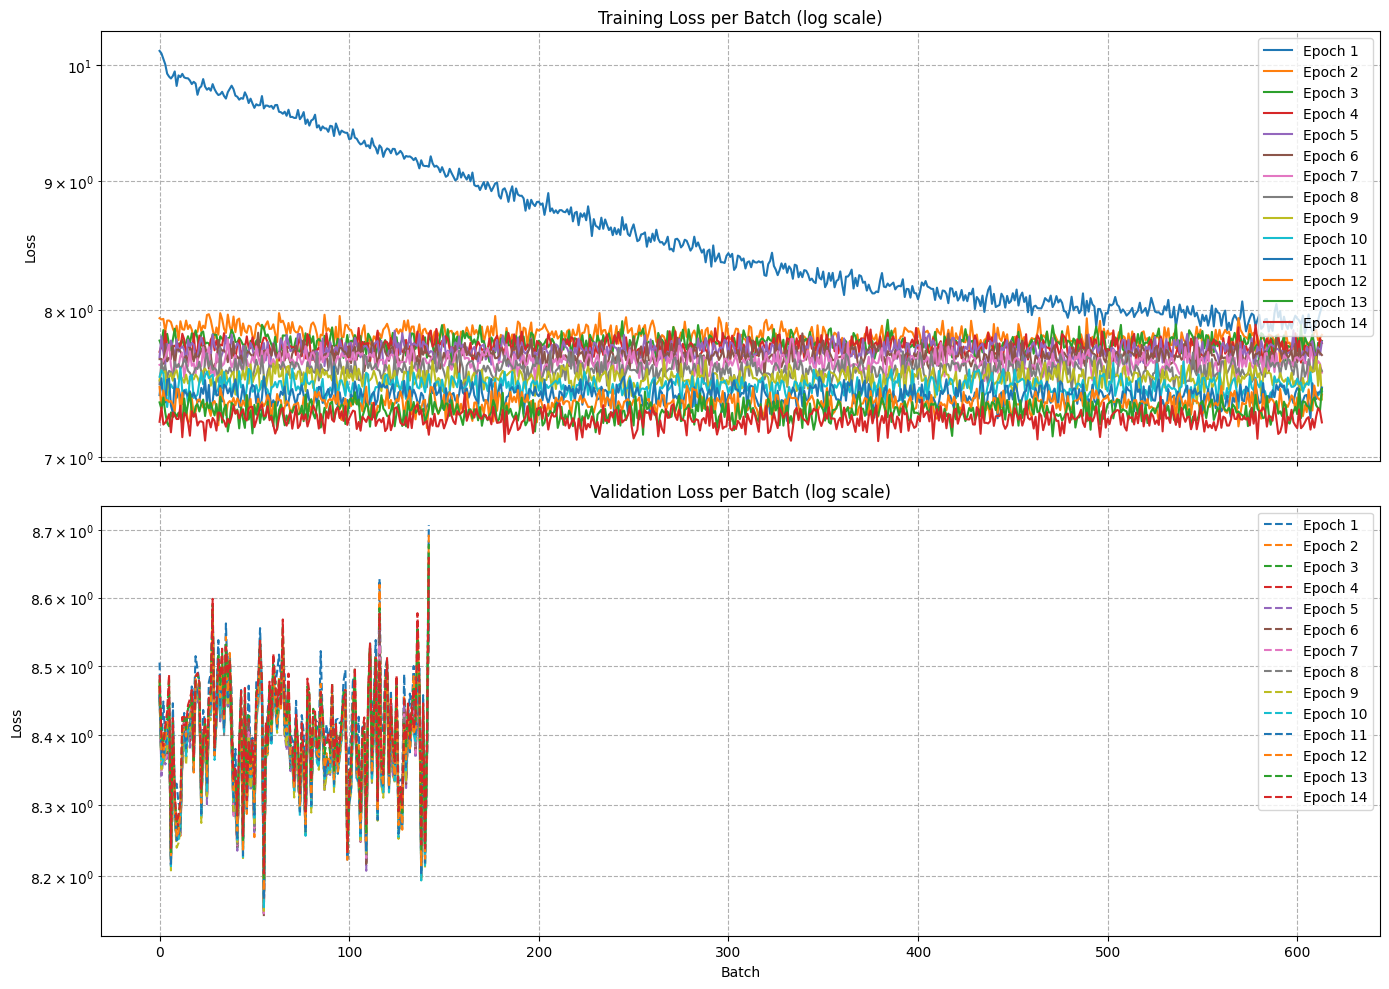

In [39]:
plot_training_history_separate(hystory, hystory_val, smooth=False )

In [40]:
model.eval()  # режим валидации
preds = []    # список для предсказаний
users = []    # список для user_id
actuals = []  # список для реальных товаров

with torch.no_grad():
    for batch in test_loader:
        seq = batch['seq'].to(device)
        target = batch['target'].to(device)
        user_idx = batch['user'].long().to(device)
        
        age = age_tensor[user_idx]
        income = income_tensor[user_idx]
        sex = sex_tensor[user_idx]
        kids = kids_tensor[user_idx]
        
        logits = model(seq, user_idx, age, income, sex, kids)
        
        # Предсказываем топ-N items для каждого пользователя (например, top 10)
        topk = 10
        top_items = torch.topk(logits, k=topk, dim=1).indices.cpu().tolist()
        
        preds.extend(top_items)
        users.extend(batch['user'].tolist())
        actuals.extend(target.cpu().tolist())

In [41]:
def metric_ratio(r, a, metric='precision'):
    """
Вычисляет Precision, Recall или F1 для списка рекомендованных и реальных элементов.

Аргументы:

    r: list — рекомендованные элементы

    a: list — реальные элементы (целевые)

    metric: str — 'precision', 'recall' или 'f1'

Возвращает:

    float — значение метрики
    """
    if not r:
        return 0.0
    common = len(set(r) & set(a))
    if metric == 'precision':
        return common / len(r)
    elif metric == 'recall':
        return common / len(a) if len(a) > 0 else 0.0
    elif metric == 'f1':
        p = common / len(r)
        r_val = common / len(a) if len(a) > 0 else 0.0
        return 2 * (p * r_val) / (p + r_val) if (p + r_val) > 0 else 0.0
    else:
        raise ValueError("Unsupported metric")

In [42]:

# flatten preds (список списков) в плоский список на пользователя
preds_flat = [list(chain.from_iterable(x)) if isinstance(x[0], list) else x for x in preds]

# actuals уже числа, оставляем как есть
actuals_flat = actuals

# создаем DataFrame
df_preds = pd.DataFrame({
    'user': users,
    'reco': preds_flat,
    'actual': actuals_flat
})

# группируем по пользователю
preds_by_user = df_preds.groupby('user')['reco'].agg(lambda x: list(chain.from_iterable(x)))
actual_by_user = df_preds.groupby('user')['actual'].agg(list)  # каждый user может иметь несколько actual

# создаем DataFrame для метрик
df_metrics = pd.DataFrame({
    'reco': preds_by_user,
    'actual': actual_by_user
}).dropna()

# Precision
precision_values = df_metrics.apply(lambda row: metric_ratio(row['reco'], row['actual'], 'precision'), axis=1)
precision = precision_values.mean()
print(f"Average Precision: {precision:.4f}")

# Recall
recall_values = df_metrics.apply(lambda row: metric_ratio(row['reco'], row['actual'], 'recall'), axis=1)
recall = recall_values.mean()
print(f"Average Recall: {recall:.4f}")

# F1
f1_values = df_metrics.apply(lambda row: metric_ratio(row['reco'], row['actual'], 'f1'), axis=1)
f1 = f1_values.mean()
print(f"Average F1: {f1:.4f}")

Average Precision: 0.0132
Average Recall: 0.1315
Average F1: 0.0239


In [47]:
df_metrics

,reco,actual
user,,
9,"[1883, 7487, 12051, 9478, 15235, 6502, 14384, ...",[8433]
24,"[3952, 12036, 9086, 1275, 11255, 5207, 15353, ...","[9580, 1275, 3876, 4689, 13695]"
27,"[12051, 6502, 15235, 1883, 4956, 4271, 9254, 5...","[14226, 7384, 6562, 1883, 6673, 1097, 9554]"
43,"[1850, 8433, 6347, 1883, 203, 9699, 3952, 6690...",[15234]
57,"[6347, 1883, 768, 12051, 6502, 13616, 6690, 96...",[3933]
...,...,...
840121,"[6347, 1883, 14890, 768, 203, 6690, 6502, 1523...",[13695]
840136,"[6347, 6502, 768, 1883, 12051, 6690, 3876, 829...",[7000]
840139,"[1883, 768, 11973, 6502, 6690, 12051, 9554, 74...","[3331, 819]"


In [43]:

def compute_embedding_metrics(
    recs_by_user: Union[Dict, pd.Series],
    actual_by_user: Union[Dict, pd.Series],
    item_embeddings: torch.Tensor,
    top_k: int = 10,
    threshold: float = 0.7,
    device: str = "cpu"
) -> Dict[str, float]:
    """
Вычисляет метрики качества рекомендаций на основе косинусного сходства эмбеддингов фильмов.

Аргументы:

    recs_by_user: dict или pd.Series — {user: list of recommended item ids}

    actual_by_user: dict или pd.Series — {user: list of actual item ids}

    item_embeddings: torch.Tensor — (num_items, emb_dim)

    top_k: int, default=10 — количество учитываемых рекомендаций на пользователя

    threshold: float, default=0.7 — порог косинусного сходства для hit rate

    device: str, default='cpu'

Возвращает:

    dict: {'avg_max_cos_sim@10', 'avg_cosine_similarity@10', 'hit_rate@10_cos>0.7'}
    """
    # Убедимся, что эмбеддинги на нужном устройстве и без градиентов
    item_embeddings = item_embeddings.to(device).detach()
    
    # Приведём входные данные к единому формату словаря
    if isinstance(recs_by_user, pd.Series):
        recs_by_user = recs_by_user.to_dict()
    if isinstance(actual_by_user, pd.Series):
        actual_by_user = actual_by_user.to_dict()
    
    # Получим общих пользователей
    common_users = set(recs_by_user.keys()) & set(actual_by_user.keys())
    if not common_users:
        print("Нет общих пользователей между рекомендациями и реальными просмотрами.")
        return {"avg_cosine_similarity": 0.0, "hit_rate": 0.0}
    
    total_cos_sim = 0.0
    total_max_cos_sim = 0.0
    total_hits = 0
    valid_users = 0
    
    for user in common_users:
        recs = recs_by_user[user][:top_k]      # обрезаем до top_k
        actual = actual_by_user[user]
        
        if not recs or not actual:
            continue
        
        # Извлекаем эмбеддинги
        rec_ids = torch.tensor(recs, device=device, dtype=torch.long)
        actual_ids = torch.tensor(actual, device=device, dtype=torch.long)
        
        # Эмбеддинги рекомендованных и реальных фильмов
        rec_embs = item_embeddings[rec_ids]       # (K, D)
        actual_embs = item_embeddings[actual_ids] # (M, D)
        
        # Вычисляем попарное косинусное сходство
        # rec_embs: (K, D), actual_embs: (M, D) -> similarity: (K, M)
        similarity = F.cosine_similarity(
            rec_embs.unsqueeze(1),   # (K, 1, D)
            actual_embs.unsqueeze(0), # (1, M, D)
            dim=2
        )  # (K, M)
        
        # Среднее сходство по всем парам
        avg_sim = similarity.mean().item()
        max_sim = similarity.max().item()
        total_max_cos_sim += max_sim
        total_cos_sim += avg_sim
        
        # Hit: есть ли пара с сходством > threshold
        if (similarity > threshold).any():
            total_hits += 1
        
        valid_users += 1
    
    if valid_users == 0:
        return {"avg_cosine_similarity": 0.0, "hit_rate": 0.0}
    
    
    avg_max_cos_sim = total_max_cos_sim / valid_users
    avg_cos_sim = total_cos_sim / valid_users
    hit_rate = total_hits / valid_users
    
    return {
        f"avg_max_cos_sim@{top_k}": avg_max_cos_sim,
        f"avg_cosine_similarity@{top_k}": avg_cos_sim,
        f"hit_rate@{top_k}_cos>{threshold}": hit_rate
    }

In [44]:
preds_by_user = df_preds.groupby('user')['reco'].agg(lambda x: list(chain.from_iterable(x)))
actual_by_user = df_preds.groupby('user')['actual'].agg(list)

# Вычисляем метрики
metrics = compute_embedding_metrics(
    recs_by_user=preds_by_user,
    actual_by_user=actual_by_user,
    item_embeddings=item_embedding,   # ваш тензор эмбеддингов фильмов
    top_k=10,
    threshold=0.7,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print(metrics)

{'avg_max_cos_sim@10': 0.6403088075909046, 'avg_cosine_similarity@10': 0.1249196391252297, 'hit_rate@10_cos>0.7': 0.47898315688954013}


Поскольку реальных достижений модель не имеет, будем довольствоваться тем, что есть.  
Расмотрим дополнительные метрики. Все они отражают не буквальное "попадание" рекомендации в фактические просмотры пользователя, а схожесть эмбеддингов предложенных фильмов с эмбеддингами просмотренных.
    
**avg_cosine_similarity@10** — Это среднее косинусное сходство эмбедингов всех предложенных и просмотренных фильмов. Метрика принимает значение от -1 до 1. В нашем случае значение примерно равно 0.125, что говорит о том, что предложенные фильмы мало чем лучше случайных  
  
**hit_rate@10_cos>0.7** — Это доля пользователей, которые получили хотя бы одну рекомендацию со схожестью выше 0.7. В нашем случае - это ~0.479, что говорит о том, что около половины пользователей получили рекомендации в сооствествии с тем, что они по итогу посмортели, пусть и не фактически тот же фильм  
  
**avg_max_cos_sim@10** — Это среднее максимальное косинусное сходство. Указывает на среднее значение лучших предложений для каждого пользователя. Значение в 0.64 говорит об умении попадать в жанр/ключевые слова с относительно высокой точностью 

In [45]:
def show_user_recommendations(user_seq, pred_topk, target, df_movies, idx2item, top_history=10):
    """
Визуализирует историю пользователя, предсказанные фильмы (Top‑N) и реальные фильмы из тестовой выборки.

Аргументы:

    user_seq: list или 1D tensor — последовательность просмотренных фильмов (индексы item2idx)

    pred_topk: list — топ-N предсказанных фильмов (индексы item2idx)

    target: list — реальные фильмы из теста (индексы item2idx)

    df_movies: DataFrame с колонками 'item_id', 'title', 'genres', 'keywords'

    idx2item: dict {index: original_item_id}

    top_history: int, default=10 — сколько последних фильмов истории показывать
    """
    # Преобразуем индексы в оригинальные item_id
    history_ids = [idx2item[idx] for idx in user_seq[-top_history:] if idx != 0]
    pred_ids = [idx2item[idx] for idx in pred_topk if idx != 0]
    target_ids = [idx2item[idx] for idx in target if idx != 0]
    
    # предыдущие фильмы
    df_history = df_movies[df_movies['item_id'].isin(history_ids)][['title','genres','keywords']]
    print("=== История пользователя (последние {} фильмов) ===".format(top_history))
    display(df_history.reset_index(drop=True))
    
    # предсказанные фильмы
    df_pred = df_movies[df_movies['item_id'].isin(pred_ids)][['title','genres','keywords']]
    print("\n=== Предсказанные фильмы (Top-N) ===")
    display(df_pred.reset_index(drop=True))
    
    # реальные фильмы из теста
    df_test = df_movies[df_movies['item_id'].isin(target_ids)][['title','genres','keywords']]
    print("\n=== Реальные фильмы (тест) ===")
    display(df_test.reset_index(drop=True))

In [46]:
# пример для одного пользователя
user_idx = 57

# последовательность истории пользователя
user_seq = batch['seq'][0].cpu().tolist()  # первый элемент батча

# top-10 предсказанных
pred_topk = torch.topk(logits[0], k=10).indices.cpu().tolist()

# реальные фильмы из target
target_list = [target[0].item()]  # если target один фильм
# если несколько фильмов: target_list = target[0].cpu().tolist()

show_user_recommendations(user_seq, pred_topk, target_list, df_items, idx2item)

=== История пользователя (последние 10 фильмов) ===


,title,genres,keywords
0,X-Men,"action, science fiction","Mutant, comic book-based superhero, superman, ..."
1,Rage,"action, drama, thriller, crime","Rioting, carnage, murder, Car chase, Bank, Ban..."
2,[4k] Dracula,"foreign, horror, fantasy, melodrama","4k, Dracula, 1992, USA, vampires, werewolves, ..."
3,Ace Ventura: Finding Pets,"adventure, detective, comedy","Miami, Florida, dolphin, detective, human-anim..."
4,The Last Witch Hunter,"action, fantasy, adventure","New York, Witch, Rebellion, Witch Hunter, Engl..."
5,Spider-Man: Homecoming,"action, science fiction, adventure","Venice, Italy, Europe, Prague, Czech Republic,..."
6,Taxi 4,"action, foreign, crime, comedy","Taxi 4, 2007, France, bandits, gangsters, lose..."
7,[4k] Hancock,"drama, foreign, comics, science fiction, actio...","4k, Hancock, 2008, USA, love, losers, pursuits..."
8,[4k] Terminator: The Genesis,"science fiction, foreign, action, thrillers","4k, Terminator, Genesis, 2015, United States, ..."
9,John Wick 2,"action, thrillers, crime","Italy, pistol, roof, party, sequel, handshake,..."



=== Предсказанные фильмы (Top-N) ===


,title,genres,keywords
0,100% Wolf,"animation, adventure, family, fantasy, comedy","poodle, teenage anxiety, werewolf, adoption, 2..."
1,The Lion King (2019),"drama, animation, music","Africa, Lion, Prince, Musical, Uncle, Remake, ..."
2,Aladdin,"fantasy, adventure, melodrama","Musical, Sultan, Flying Carpet, Monkey, First ..."
3,Pirates of the Caribbean: Dead Men Tell No Tales,"action, fantasy, adventure","Sea, ship, sequel, artifact, treasure map, pir..."
4,Ratatouille,"animation, adventure, drama, fantasy, comedy","Paris, France, kinship, expensive restaurant, ..."
5,Black Panther,"action, science fiction, adventure","Afrika, Superhero, based on comics, 1990's, 20..."
6,Avengers: Infinity War,"action, science fiction, adventure","Heroic, Victim, Superhero, Comics, Space, Batt..."
7,The Superfamily,"science fiction, animation, adventure","Secret Personality, Secret, Hero, Island, Vill..."
8,Iron Man 3,"action, science fiction, adventure","War on Terror, Tennessee, Malibu, Superhero, b..."
9,Guardians of the Galaxy - Part 2,"action, science fiction, adventure, comedy","sequels, superhero based on comics, space, 198..."



=== Реальные фильмы (тест) ===


,title,genres,keywords
0,28 Panfilov,"drama, historical, military","Germany, Hero, World War II, Russia, Nazis, So..."
